# KNN Classification & Regression — Spotify Dataset
**Dataset:** Spotify Tracks dataset (`spotify.csv`)

### Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    r2_score, mean_absolute_error, mean_squared_error
)
from math import sqrt


### Load & Explore the Dataset

In [4]:
df = pd.read_csv('spotify.csv')
print('Dataset Shape:', df.shape)
df.head()

Dataset Shape: (114000, 21)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [5]:
print('Missing values:')
print(df.isnull().sum())
print('\nColumn types:')
print(df.dtypes)

Missing values:
Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

Column types:
Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence           

In [6]:
print('Statistical Summary (numeric features):')
df[['popularity','danceability','energy','loudness','tempo']].describe()

Statistical Summary (numeric features):


,popularity,danceability,energy,loudness,tempo
count,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,0.566800,0.641383,-8.258960,122.147837
std,22.305078,0.173542,0.251529,5.029337,29.978197
min,0.000000,0.000000,0.000000,-49.531000,0.000000
25%,17.000000,0.456000,0.472000,-10.013000,99.218750
50%,35.000000,0.580000,0.685000,-7.004000,122.017000
75%,50.000000,0.695000,0.854000,-5.003000,140.071000
max,100.000000,0.985000,1.000000,4.532000,243.372000


### EDA

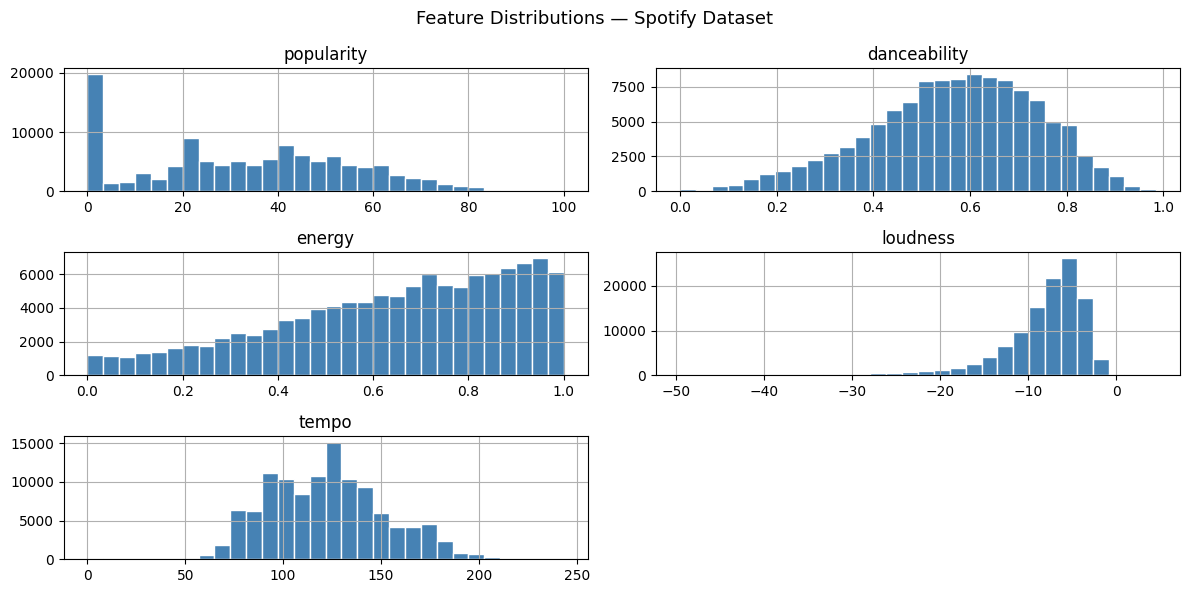

In [7]:
# Feature distributions
df[['popularity','danceability','energy','loudness','tempo']].hist(
    figsize=(12, 6), bins=30, color='steelblue', edgecolor='white'
)
plt.suptitle('Feature Distributions — Spotify Dataset', fontsize=13)
plt.tight_layout()
plt.show()

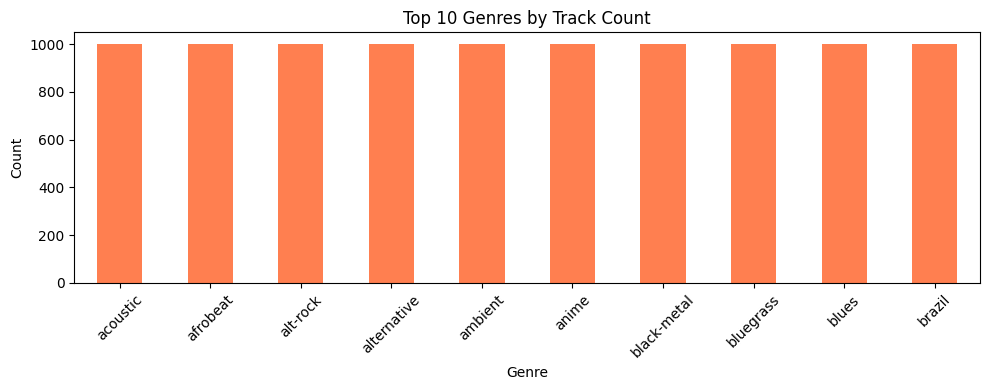

In [8]:
# Top 10 genres by count
plt.figure(figsize=(10, 4))
df['track_genre'].value_counts().head(10).plot(kind='bar', color='coral')
plt.title('Top 10 Genres by Track Count')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### KNN Classification
Classify the `track_genre` using audio features

### Preprocessing for Classification

In [9]:
# Drop rows with missing values and duplicate tracks
df_cls = df.copy()
df_cls.dropna(inplace=True)
df_cls.drop_duplicates(subset='track_id', inplace=True)

# Drop non-feature text columns
drop_cols = [c for c in ['Unnamed: 0','track_id','artists','album_name','track_name'] if c in df_cls.columns]
df_cls.drop(columns=drop_cols, inplace=True)
df_cls['explicit'] = df_cls['explicit'].astype(int)

# Use top 5 genres to keep classification tractable
top5 = df_cls['track_genre'].value_counts().head(5).index
df_cls = df_cls[df_cls['track_genre'].isin(top5)].reset_index(drop=True)

print('Working shape:', df_cls.shape)
print('Genres:', list(df_cls['track_genre'].unique()))

Working shape: (4996, 16)
Genres: ['acoustic', 'afrobeat', 'alt-rock', 'ambient', 'cantopop']


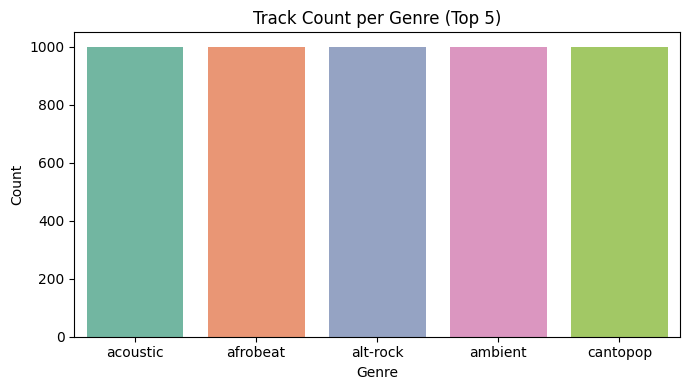

In [10]:
# Class distribution (after filtering top 5)
plt.figure(figsize=(7, 4))
sns.countplot(x='track_genre', data=df_cls, palette='Set2')
plt.title('Track Count per Genre (Top 5)')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [12]:
features = ['danceability','energy','loudness','speechiness',
            'acousticness','instrumentalness','liveness','valence','tempo']

X_cls = df_cls[features]
le    = LabelEncoder()
y_cls = le.fit_transform(df_cls['track_genre'])

print('Classes:', le.classes_)
print('Feature shape:', X_cls.shape)

Classes: ['acoustic' 'afrobeat' 'alt-rock' 'ambient' 'cantopop']
Feature shape: (4996, 9)


### Train-Test Split & Scaling (Classification)

In [13]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.2, stratify=y_cls, random_state=42
)

scaler_c  = StandardScaler()
X_train_c = scaler_c.fit_transform(X_train_c)
X_test_c  = scaler_c.transform(X_test_c)

print(f'Train: {X_train_c.shape} | Test: {X_test_c.shape}')

Train: (3996, 9) | Test: (1000, 9)


### Find Optimal K for Classification

In [14]:
from sklearn.metrics import f1_score

f1_scores = []
k_range   = range(1, 21)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn.fit(X_train_c, y_train_c)
    pred = knn.predict(X_test_c)
    f1   = f1_score(y_test_c, pred, average='macro')
    f1_scores.append(f1)
    print(f'K={k:2d} | F1 Score (Macro): {f1:.4f}')

best_k_c = list(k_range)[f1_scores.index(max(f1_scores))]
print(f'\nBest K = {best_k_c} | Best F1 = {max(f1_scores):.4f}')

K= 1 | F1 Score (Macro): 0.5988
K= 2 | F1 Score (Macro): 0.5941
K= 3 | F1 Score (Macro): 0.6219
K= 4 | F1 Score (Macro): 0.6212
K= 5 | F1 Score (Macro): 0.6283
K= 6 | F1 Score (Macro): 0.6264
K= 7 | F1 Score (Macro): 0.6256
K= 8 | F1 Score (Macro): 0.6395
K= 9 | F1 Score (Macro): 0.6362
K=10 | F1 Score (Macro): 0.6304
K=11 | F1 Score (Macro): 0.6276
K=12 | F1 Score (Macro): 0.6237
K=13 | F1 Score (Macro): 0.6216
K=14 | F1 Score (Macro): 0.6268
K=15 | F1 Score (Macro): 0.6312
K=16 | F1 Score (Macro): 0.6240
K=17 | F1 Score (Macro): 0.6270
K=18 | F1 Score (Macro): 0.6248
K=19 | F1 Score (Macro): 0.6282
K=20 | F1 Score (Macro): 0.6291

Best K = 8 | Best F1 = 0.6395


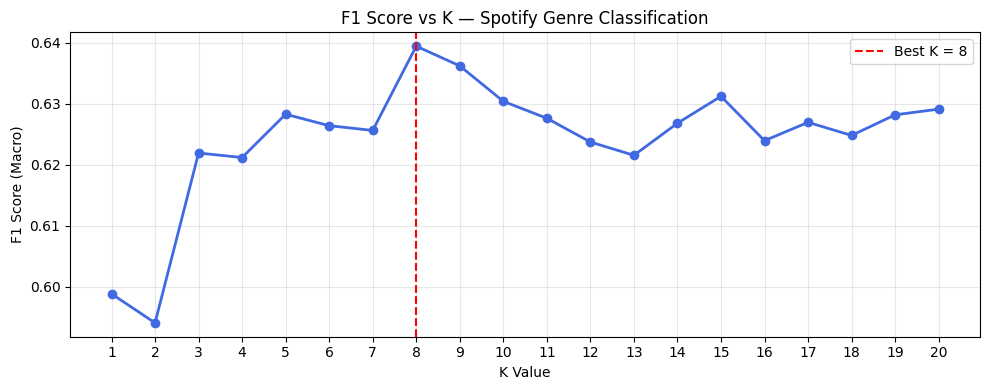

In [15]:
plt.figure(figsize=(10, 4))
plt.plot(list(k_range), f1_scores, marker='o', color='royalblue', linewidth=2)
plt.axvline(x=best_k_c, color='red', linestyle='--', label=f'Best K = {best_k_c}')
plt.xlabel('K Value')
plt.ylabel('F1 Score (Macro)')
plt.title('F1 Score vs K — Spotify Genre Classification')
plt.xticks(list(k_range))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Final Classification Model & Evaluation

In [16]:
knn_cls = KNeighborsClassifier(n_neighbors=best_k_c, n_jobs=-1)
knn_cls.fit(X_train_c, y_train_c)
y_pred_c = knn_cls.predict(X_test_c)

print(f'=== Classification Results (K={best_k_c}) ===')
print(f'Accuracy: {accuracy_score(y_test_c, y_pred_c):.4f}\n')
print('Classification Report:')
print(classification_report(y_test_c, y_pred_c, target_names=le.classes_))

=== Classification Results (K=8) ===
Accuracy: 0.6350

Classification Report:
              precision    recall  f1-score   support

    acoustic       0.44      0.49      0.47       200
    afrobeat       0.73      0.70      0.71       200
    alt-rock       0.61      0.62      0.61       200
     ambient       0.86      0.76      0.81       200
    cantopop       0.59      0.60      0.60       200

    accuracy                           0.64      1000
   macro avg       0.65      0.64      0.64      1000
weighted avg       0.65      0.64      0.64      1000



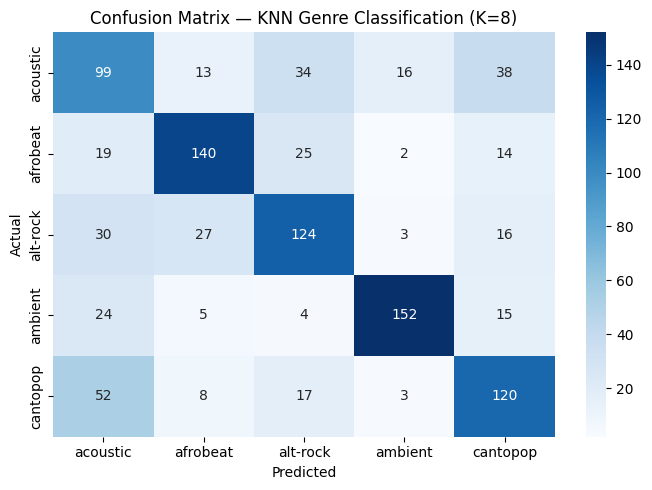

In [17]:
cm = confusion_matrix(y_test_c, y_pred_c)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix — KNN Genre Classification (K={best_k_c})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

##  KNN Regression
Predict `popularity` score (0–100) from audio features

### Preprocessing for Regression

In [18]:
df_reg = df.copy()
df_reg.dropna(inplace=True)
df_reg.drop_duplicates(subset='track_id', inplace=True)

drop_cols_r = [c for c in ['Unnamed: 0','track_id','artists','album_name','track_name'] if c in df_reg.columns]
df_reg.drop(columns=drop_cols_r, inplace=True)
df_reg['explicit'] = df_reg['explicit'].astype(int)

print('Regression dataset shape:', df_reg.shape)
print('\nPopularity stats:')
print(df_reg['popularity'].describe())

Regression dataset shape: (89740, 16)

Popularity stats:
count    89740.000000
mean        33.198808
std         20.580640
min          0.000000
25%         19.000000
50%         33.000000
75%         49.000000
max        100.000000
Name: popularity, dtype: float64


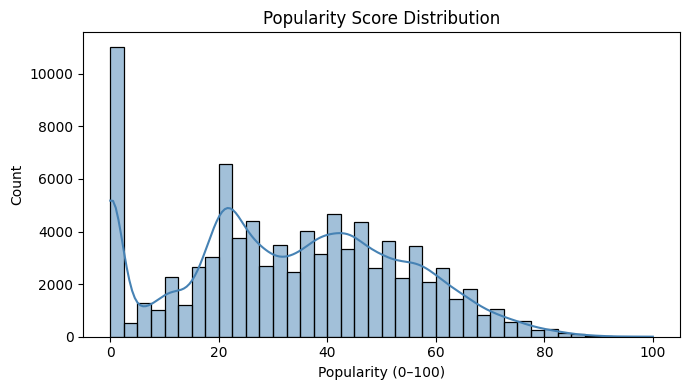

In [19]:
# Popularity distribution
plt.figure(figsize=(7, 4))
sns.histplot(df_reg['popularity'], bins=40, kde=True, color='steelblue')
plt.title('Popularity Score Distribution')
plt.xlabel('Popularity (0–100)')
plt.tight_layout()
plt.show()

Train-Test Split & Scaling (Regression)

In [20]:
reg_features = ['danceability','energy','loudness','speechiness',
                'acousticness','instrumentalness','liveness','valence','tempo']

X_reg = df_reg[reg_features]
y_reg = df_reg['popularity']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

scaler_r  = StandardScaler()
X_train_r = scaler_r.fit_transform(X_train_r)
X_test_r  = scaler_r.transform(X_test_r)

print(f'Train: {X_train_r.shape} | Test: {X_test_r.shape}')

Train: (71792, 9) | Test: (17948, 9)


Find Optimal K for Regression (RMSE Elbow Curve)

In [ ]:
rmse_list = []
k_range_r = range(1, 21)

for k in k_range_r:
    knn_r = KNeighborsRegressor(n_neighbors=k)
    knn_r.fit(X_train_r, y_train_r)
    pred_r = knn_r.predict(X_test_r)
    rmse   = sqrt(mean_squared_error(y_test_r, pred_r))
    rmse_list.append(rmse)
    print(f'K={k:2d} | RMSE: {rmse:.4f}')

best_k_r = list(k_range_r)[rmse_list.index(min(rmse_list))]
print(f'\nBest K = {best_k_r} | Lowest RMSE = {min(rmse_list):.4f}')

K= 1 | RMSE: 24.9118
K= 2 | RMSE: 22.1856
K= 3 | RMSE: 21.0764
K= 4 | RMSE: 20.6192
K= 5 | RMSE: 20.3208
K= 6 | RMSE: 20.1073
K= 7 | RMSE: 19.9400
K= 8 | RMSE: 19.8337
K= 9 | RMSE: 19.7735
K=10 | RMSE: 19.7344
K=11 | RMSE: 19.7112
K=12 | RMSE: 19.6821
K=13 | RMSE: 19.6456


In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(list(k_range_r), rmse_list, marker='o', color='darkorange', linewidth=2)
plt.axvline(x=best_k_r, color='red', linestyle='--', label=f'Best K = {best_k_r}')
plt.xlabel('K Value')
plt.ylabel('RMSE')
plt.title('RMSE vs K (Elbow Curve) — Spotify Regression')
plt.xticks(list(k_range_r))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Final Regression Model & Evaluation

In [ ]:
knn_reg = KNeighborsRegressor(n_neighbors=best_k_r)
knn_reg.fit(X_train_r, y_train_r)
y_pred_r = knn_reg.predict(X_test_r)

r2   = r2_score(y_test_r, y_pred_r)
mae  = mean_absolute_error(y_test_r, y_pred_r)
rmse = sqrt(mean_squared_error(y_test_r, y_pred_r))

print(f'=== Regression Results (K={best_k_r}) ===')
print(f'R² Score : {r2:.4f}')
print(f'MAE      : {mae:.4f}')
print(f'RMSE     : {rmse:.4f}')

In [ ]:
# Actual vs Predicted
plt.figure(figsize=(7, 5))
plt.scatter(y_test_r, y_pred_r, alpha=0.1, s=8, color='steelblue', label='Predictions')
plt.plot([0, 100], [0, 100], 'r--', linewidth=2, label='Perfect Fit')
plt.xlabel('Actual Popularity')
plt.ylabel('Predicted Popularity')
plt.title(f'Actual vs Predicted Popularity — KNN (K={best_k_r})')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Residual distribution
residuals = y_test_r - y_pred_r
plt.figure(figsize=(7, 4))
sns.histplot(residuals, bins=40, kde=True, color='darkorange')
plt.axvline(0, color='red', linestyle='--')
plt.title('Residual Distribution — KNN Regression (Spotify)')
plt.xlabel('Residual (Actual - Predicted)')
plt.tight_layout()
plt.show()